In [66]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [67]:
class Network(nn.Module):
    def __init__(self):
        super().__init__()

        self.hidden = nn.Linear(1, 16)
        self.relu = nn.ReLU()
        self.output = nn.Linear(16, 1)

    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x

In [77]:
class ToyDataset(Dataset):
    def __init__(self):
        self.x = torch.linspace(-1, 1, 100).unsqueeze(1)
        self.y = 2 * self.x + 1 + torch.randn(100, 1) * 0.5

    def __len__(self):
        return len(self.x)

    def __getitem__(self, index):
        return self.x[index], self.y[index]

In [78]:
torch.manual_seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = ToyDataset()
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

model = Network().to(device)

# Baseline

In [79]:
loss_function = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

EPOCHS = 20
baseline_losses = []

for epoch in range(EPOCHS):

    total_loss = 0

    for inputs, targets in dataloader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(dataloader)
    baseline_losses.append(average_loss)

    print(f"Baseline Epoch {epoch + 1}: Loss = {average_loss:.4f}")

Baseline Epoch 1: Loss = 1.7126
Baseline Epoch 2: Loss = 1.3104
Baseline Epoch 3: Loss = 1.1681
Baseline Epoch 4: Loss = 0.9653
Baseline Epoch 5: Loss = 0.9815
Baseline Epoch 6: Loss = 0.6816
Baseline Epoch 7: Loss = 0.5421
Baseline Epoch 8: Loss = 0.5276
Baseline Epoch 9: Loss = 0.4283
Baseline Epoch 10: Loss = 0.3865
Baseline Epoch 11: Loss = 0.3225
Baseline Epoch 12: Loss = 0.2909
Baseline Epoch 13: Loss = 0.2888
Baseline Epoch 14: Loss = 0.2557
Baseline Epoch 15: Loss = 0.2539
Baseline Epoch 16: Loss = 0.3146
Baseline Epoch 17: Loss = 0.2437
Baseline Epoch 18: Loss = 0.2518
Baseline Epoch 19: Loss = 0.2292
Baseline Epoch 20: Loss = 0.2184


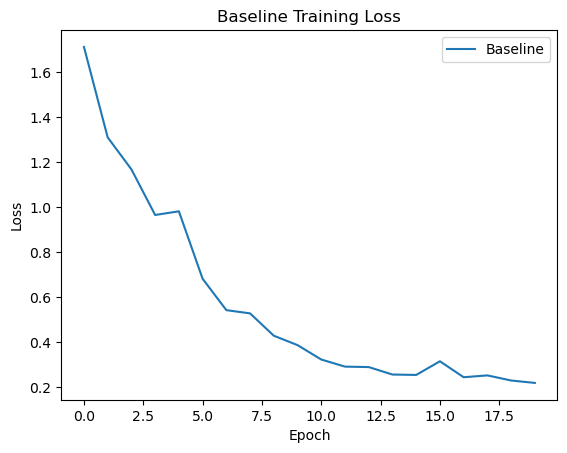

In [80]:
plt.plot(baseline_losses, label="Baseline")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Training Loss")
plt.legend()
plt.show()

# Variation

In [81]:
torch.manual_seed(7)
variation_model = Network().to(device)
variation_optimizer = torch.optim.SGD(variation_model.parameters(), lr=0.05)
variation_losses = []

for epoch in range(EPOCHS):

    total_loss = 0

    for inputs, targets in dataloader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        variation_optimizer.zero_grad()
        outputs = variation_model(inputs)
        loss = loss_function(outputs, targets)
        loss.backward()
        variation_optimizer.step()
        total_loss += loss.item()

    average_loss = total_loss / len(dataloader)
    variation_losses.append(average_loss)

    print(f"Variation Epoch {epoch + 1}: Loss = {average_loss:.4f}")

Variation Epoch 1: Loss = 1.4355
Variation Epoch 2: Loss = 0.5470
Variation Epoch 3: Loss = 0.2760
Variation Epoch 4: Loss = 0.2777
Variation Epoch 5: Loss = 0.2417
Variation Epoch 6: Loss = 0.2286
Variation Epoch 7: Loss = 0.2344
Variation Epoch 8: Loss = 0.2358
Variation Epoch 9: Loss = 0.2243
Variation Epoch 10: Loss = 0.2156
Variation Epoch 11: Loss = 0.2532
Variation Epoch 12: Loss = 0.2504
Variation Epoch 13: Loss = 0.2609
Variation Epoch 14: Loss = 0.2100
Variation Epoch 15: Loss = 0.2258
Variation Epoch 16: Loss = 0.2185
Variation Epoch 17: Loss = 0.2310
Variation Epoch 18: Loss = 0.2289
Variation Epoch 19: Loss = 0.2580
Variation Epoch 20: Loss = 0.2236


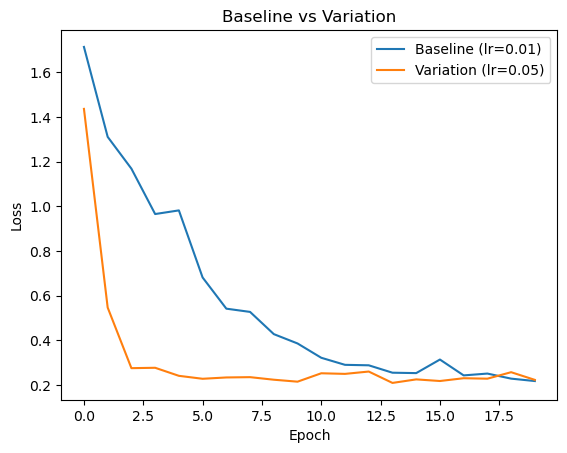

In [82]:
plt.plot(baseline_losses, label="Baseline (lr=0.01)")
plt.plot(variation_losses, label="Variation (lr=0.05)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline vs Variation")
plt.legend()
plt.show()